##Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import r_regression, mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

##Load dataset

In [ ]:
dataset = load_diabetes()

X, y = load_diabetes(return_X_y=True)

feature_names = dataset.feature_names

##Quick dataset inspection

In [ ]:
print("Features:", feature_names)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
X shape: (442, 10)
y shape: (442,)


##Split training and testing sets


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

##Verify split sizes

In [ ]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (331, 10)
Testing: (111, 10)


##Build dataframe for visualization

In [ ]:
df = pd.DataFrame(X_train, columns=feature_names)
df["target"] = y_train

##Pairplot sample visualization



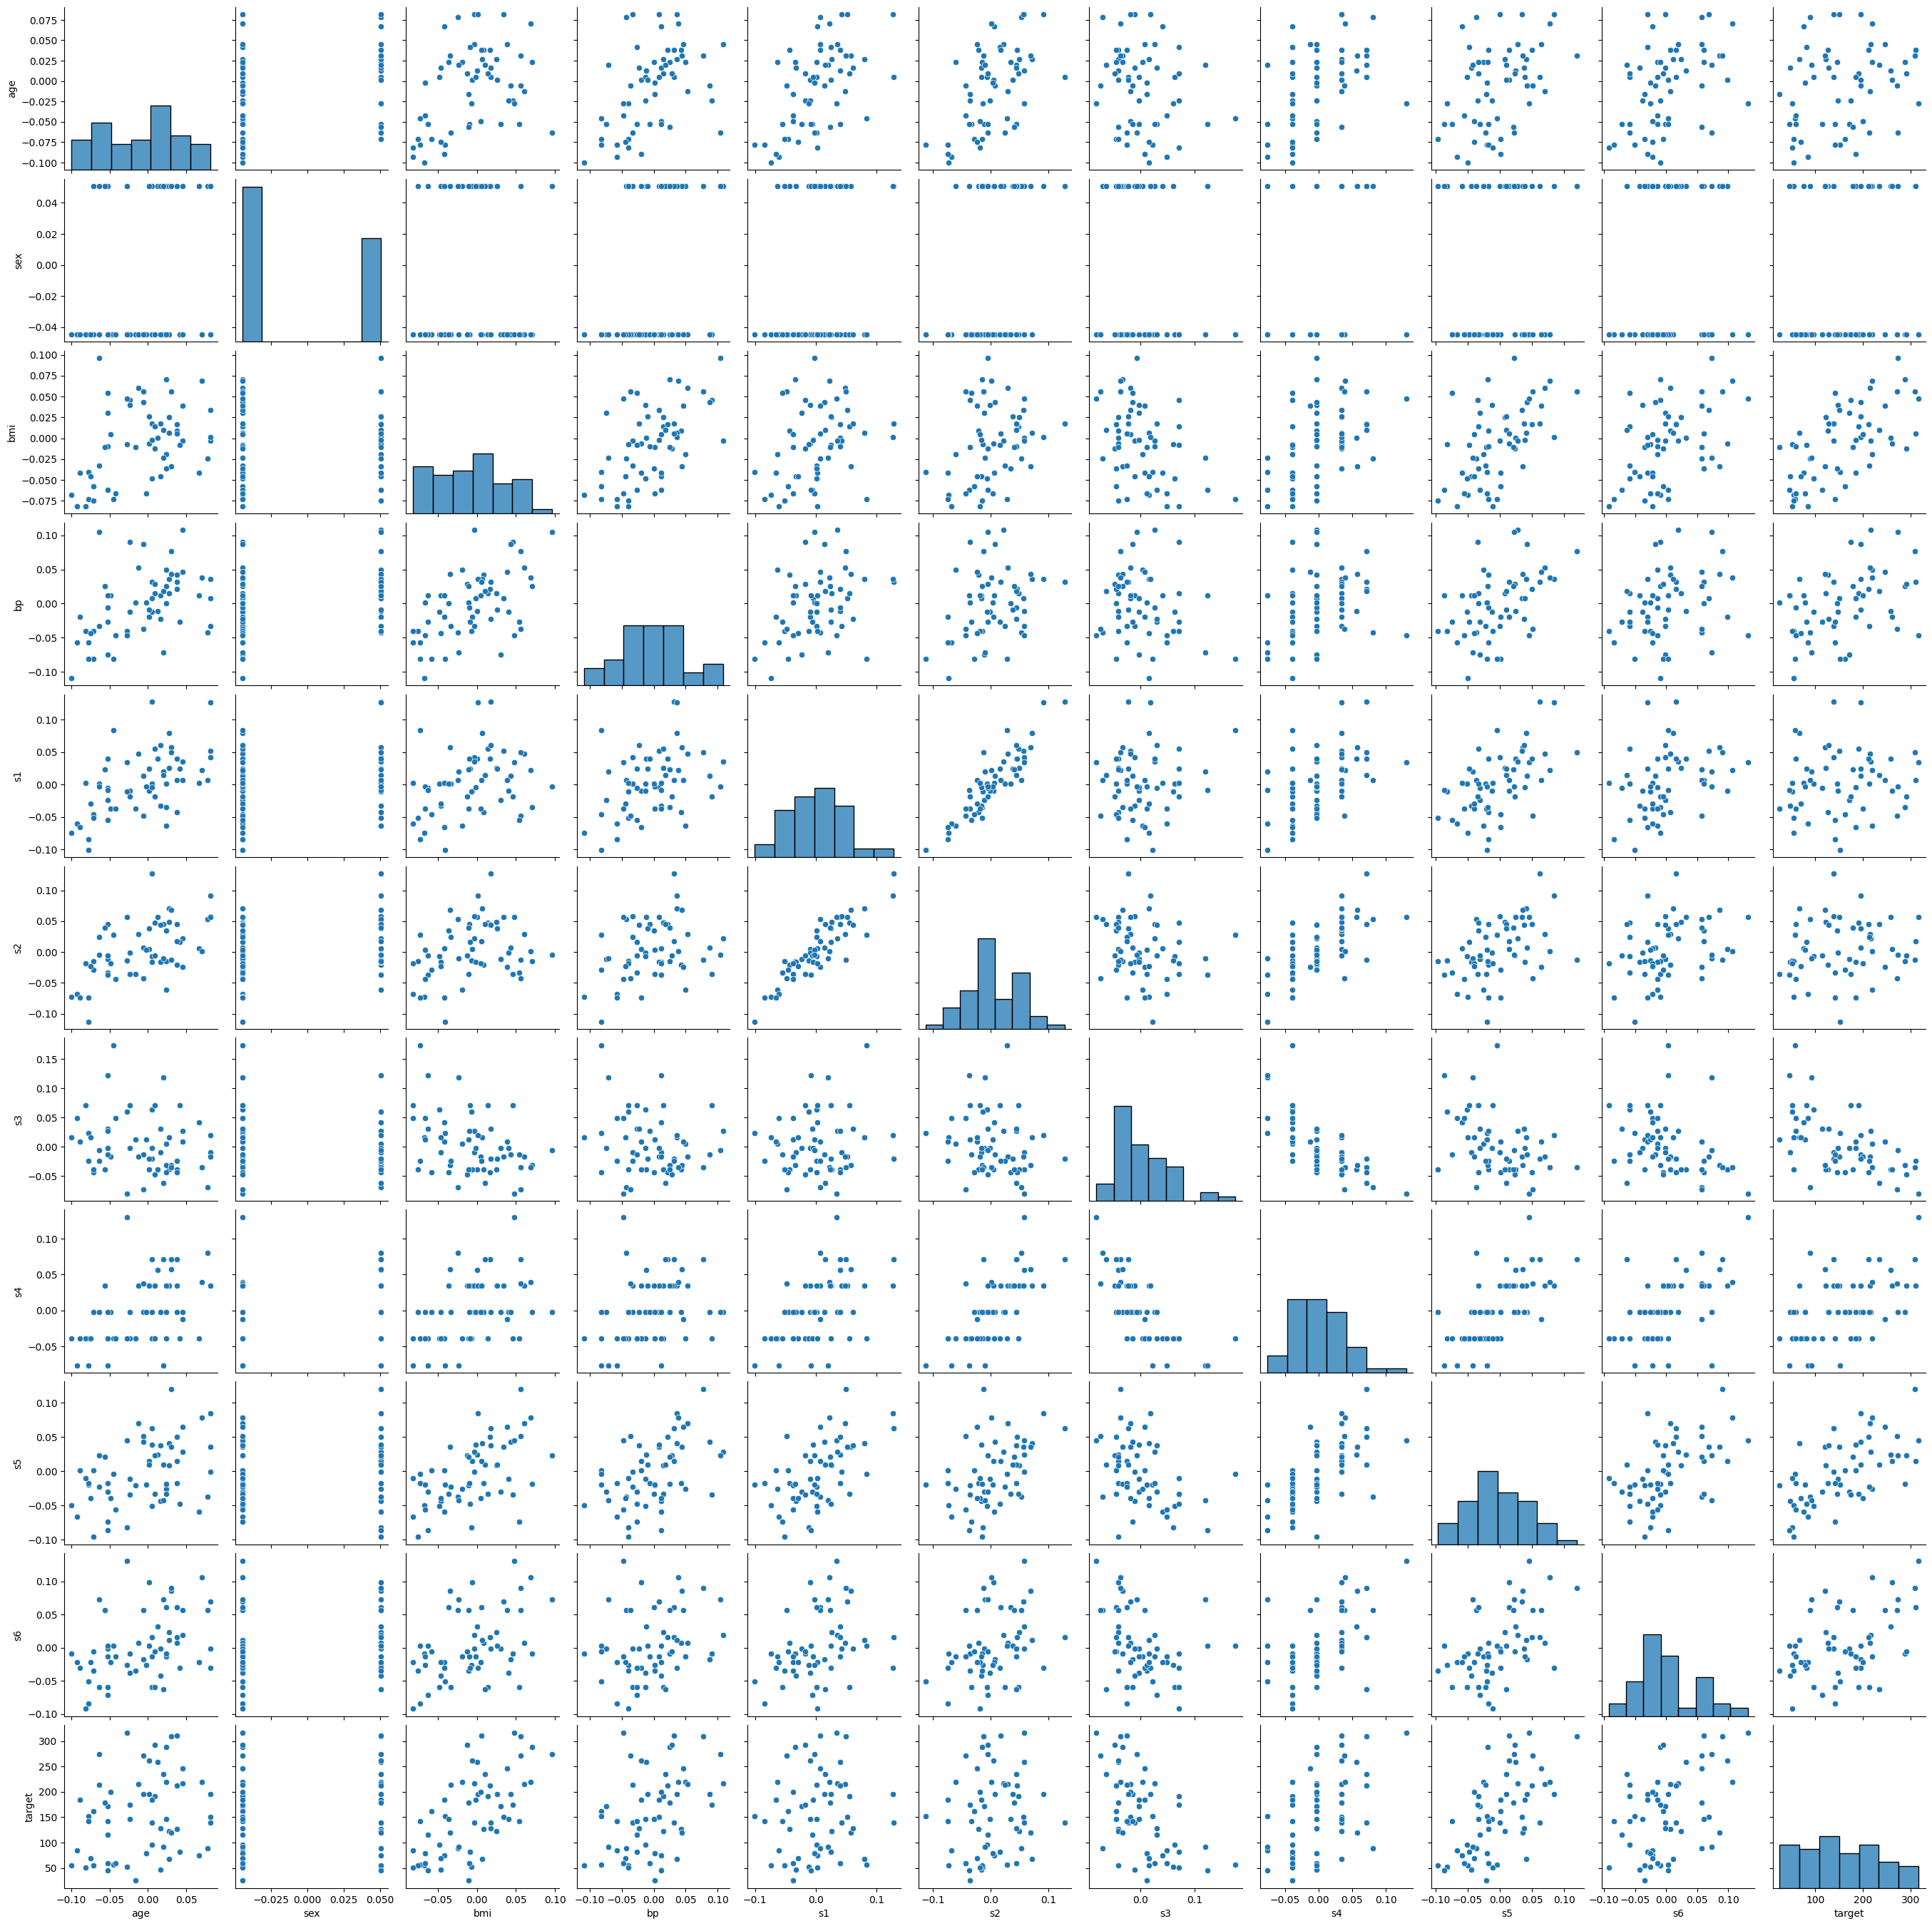

In [ ]:
sns.pairplot(df.sample(60))
plt.show()

##Pearson correlation feature ranking


In [ ]:
corr_scores = r_regression(X_train, y_train)

corr_order = np.argsort(np.abs(corr_scores))[::-1]

sorted_corr = np.array(feature_names)[corr_order]
sorted_corr_scores = corr_scores[corr_order]

##Pearson plot

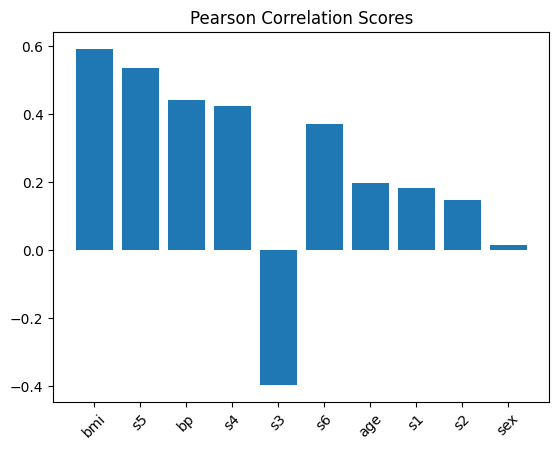

In [ ]:
plt.bar(sorted_corr, sorted_corr_scores)
plt.xticks(rotation=45)
plt.title("Pearson Correlation Scores")
plt.show()

##Top Pearson features

In [ ]:
for i in range(5):
    print(sorted_corr[i], sorted_corr_scores[i])

bmi 0.5913305769318465
s5 0.5343956117596458
bp 0.4416701608600009
s4 0.42397298254188354
s3 -0.397251174318823


##Mutual information ranking

In [ ]:
mi_scores = mutual_info_regression(X_train, y_train, random_state=42)

mi_order = np.argsort(mi_scores)[::-1]

sorted_mi = np.array(feature_names)[mi_order]
sorted_mi_scores = mi_scores[mi_order]

##Mutual information plot

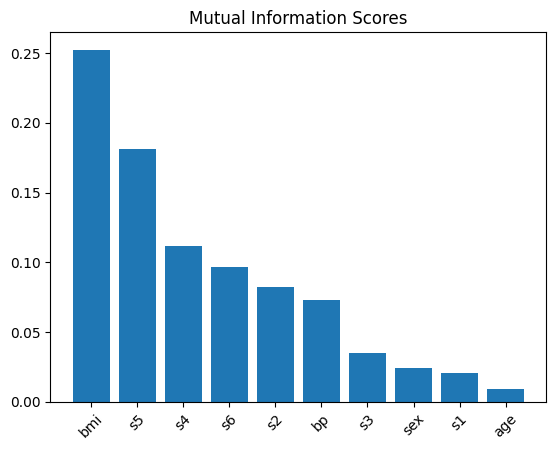

In [ ]:
plt.bar(sorted_mi, sorted_mi_scores)
plt.xticks(rotation=45)
plt.title("Mutual Information Scores")
plt.show()

##Top mutual info features

In [ ]:
for i in range(5):
    print(sorted_mi[i], sorted_mi_scores[i])

bmi 0.2522936403155325
s5 0.18126843721828712
s4 0.11134107503702273
s6 0.09667537744402033
s2 0.08197044614548199


##Random forest feature importance


In [ ]:
forest = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

forest.fit(X_train, y_train)

forest_scores = forest.feature_importances_

##Sort random forest importance

In [ ]:
forest_order = np.argsort(forest_scores)[::-1]

sorted_forest = np.array(feature_names)[forest_order]
sorted_forest_scores = forest_scores[forest_order]

##Random forest plot

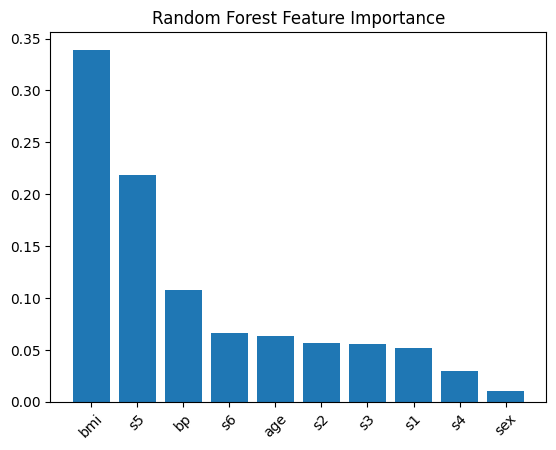

In [ ]:
plt.bar(sorted_forest, sorted_forest_scores)
plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance")
plt.show()

##Top random forest features

In [ ]:
for i in range(5):
    print(sorted_forest[i], sorted_forest_scores[i])

bmi 0.3391294358047382
s5 0.21883216057531205
bp 0.1074126883537659
s6 0.06665413174867015
age 0.06297932967577372


##Recursive Feature Elimination


In [ ]:
svr = SVR(kernel="linear")

selector = RFE(
    estimator=svr,
    n_features_to_select=5
)

selector.fit(X_train, y_train)

RFE(estimator=SVR(kernel='linear'), n_features_to_select=5)

##RFE rankings

In [ ]:
rfe_order = np.argsort(selector.ranking_)

sorted_rfe = np.array(feature_names)[rfe_order]
sorted_ranks = selector.ranking_[rfe_order]

##Display RFE result

In [ ]:
for i in range(len(sorted_rfe)):
    print(sorted_rfe[i], sorted_ranks[i])

bp 1
bmi 1
s3 1
s4 1
s5 1
s6 2
age 3
s1 4
s2 5
sex 6


##Best 5 RFE features

In [ ]:
print("Top 5 selected features:")
print(sorted_rfe[:5])

Top 5 selected features:
['bp' 'bmi' 's3' 's4' 's5']


##Summary

Different feature selection methods produce slightly different rankings because each one measures predictor usefulness differently.

Pearson captures linear association

Mutual information detects broader dependency

Random forest evaluates contribution inside trees

RFE removes weaker variables iteratively

Features that remain near the top across methods are likely consistently important.